# Tutorial 9: Visualization

**Duration:** 20-25 minutes

This tutorial covers how to create publication-quality figures using spatialtissuepy's visualization module.

## Learning Objectives

By the end of this tutorial, you will be able to:
- Configure publication styles for different journals
- Create spatial scatter plots with custom styling
- Build multi-panel figures
- Visualize statistics, networks, and analysis results
- Export figures in multiple formats

## Prerequisites

- Tutorials 1-8 completed
- Basic matplotlib knowledge

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spatialtissuepy import SpatialTissueData
from spatialtissuepy.statistics import ripleys_h, colocalization_matrix
from spatialtissuepy.network import CellGraph
from spatialtissuepy.lda import fit_spatial_lda

# Import visualization functions
from spatialtissuepy.viz import (
    # Configuration
    set_publication_style,
    set_default_style,
    get_cell_type_colors,
    get_categorical_palette,
    save_figure,
    # Spatial plots
    plot_spatial_scatter,
    plot_cell_types,
    plot_marker_expression,
    plot_density_map,
    # Network plots
    plot_cell_graph,
    plot_degree_distribution,
    plot_type_mixing_matrix,
    # Statistics plots
    plot_ripleys_curve,
    plot_colocalization_heatmap,
    plot_hotspot_map,
    # Comparison plots
    plot_violin_comparison,
    # LDA plots
    plot_topic_composition,
    plot_topic_spatial,
)

np.random.seed(42)

### Create sample data

In [2]:
# Create synthetic tissue
tumor = np.random.normal(loc=[500, 500], scale=100, size=(200, 2))
immune = np.random.normal(loc=[500, 500], scale=180, size=(100, 2))
stromal = np.random.uniform(0, 1000, size=(100, 2))

coordinates = np.vstack([tumor, immune, stromal])
cell_types = np.array(['Tumor']*200 + ['CD8_T_cell']*100 + ['Stromal']*100)

# Add marker data
markers = pd.DataFrame({
    'CD8': np.random.lognormal(2, 1, 400),
    'PD1': np.random.lognormal(1.5, 0.8, 400),
    'Ki67': np.random.uniform(0, 100, 400)
})

tissue = SpatialTissueData(coordinates=coordinates, cell_types=cell_types, markers=markers)
print(tissue)

SpatialTissueData
  Cells: 400
  Dimensions: 2D
  Cell types: 3
  Markers: 3
  Bounds: x=[13.0, 1054.2], y=[4.6, 996.9]


## Section 1: Publication Styles

### 1.1 Built-in Journal Styles

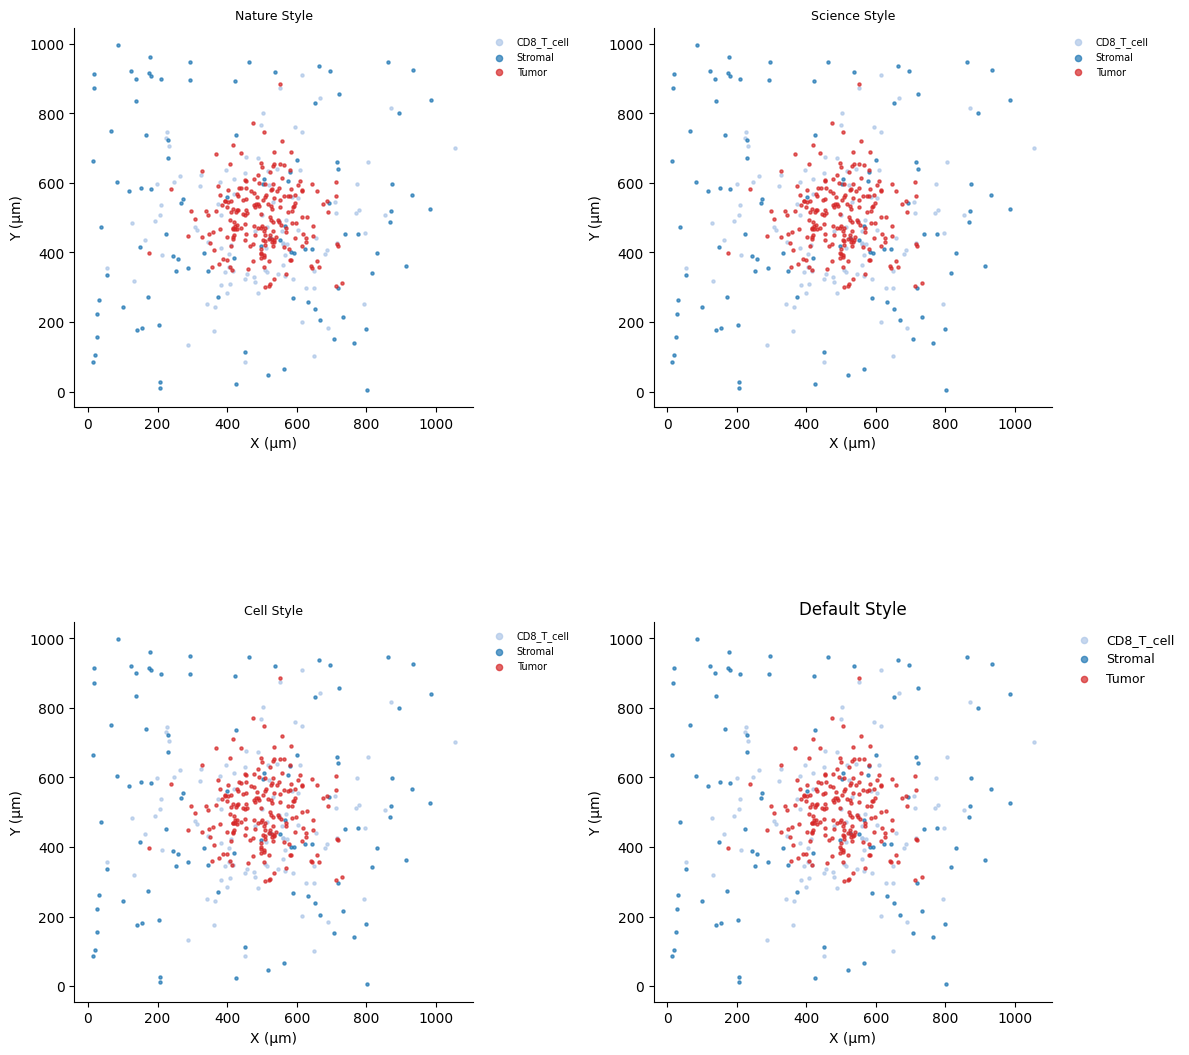

PlotConfig(figsize=(8, 6), dpi=150, font_family='sans-serif', font_size=10, title_size=12, label_size=10, tick_size=9, legend_size=9, line_width=1.5, marker_size=20, alpha=0.7, cell_type_colors={'T_cell': '#1f77b4', 'CD4_T_cell': '#1f77b4', 'CD8_T_cell': '#aec7e8', 'Treg': '#17becf', 'B_cell': '#2ca02c', 'Macrophage': '#ff7f0e', 'M1_Macrophage': '#ff7f0e', 'M2_Macrophage': '#ffbb78', 'Dendritic': '#9467bd', 'NK_cell': '#8c564b', 'Neutrophil': '#e377c2', 'Monocyte': '#7f7f7f', 'Tumor': '#d62728', 'Cancer': '#d62728', 'Tumor_proliferating': '#ff9896', 'Tumor_hypoxic': '#8b0000', 'Fibroblast': '#bcbd22', 'CAF': '#bcbd22', 'Endothelial': '#17becf', 'Epithelial': '#98df8a', 'Unknown': '#c7c7c7', 'Other': '#c7c7c7'}, categorical_palette='default', sequential_cmap='viridis', diverging_cmap='RdBu_r', show_grid=False, grid_alpha=0.3, despine=True)

In [3]:
# Compare different journal styles
styles = ['nature', 'science', 'cell', 'default']

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for ax, style in zip(axes.flat, styles):
    if style == 'default':
        set_default_style()
    else:
        set_publication_style(journal=style)
    
    plot_spatial_scatter(tissue, ax=ax)
    ax.set_title(f'{style.capitalize()} Style')

plt.tight_layout()
plt.show()

# Reset to default
set_default_style()

### 1.2 Custom Color Palettes

In [4]:
# Get default cell type colors
colors = get_cell_type_colors(tissue.cell_types_unique)
print("Default cell type colors:")
for ct, color in colors.items():
    print(f"  {ct}: {color}")

Default cell type colors:
  CD8_T_cell: #aec7e8
  Stromal: #1f77b4
  Tumor: #d62728


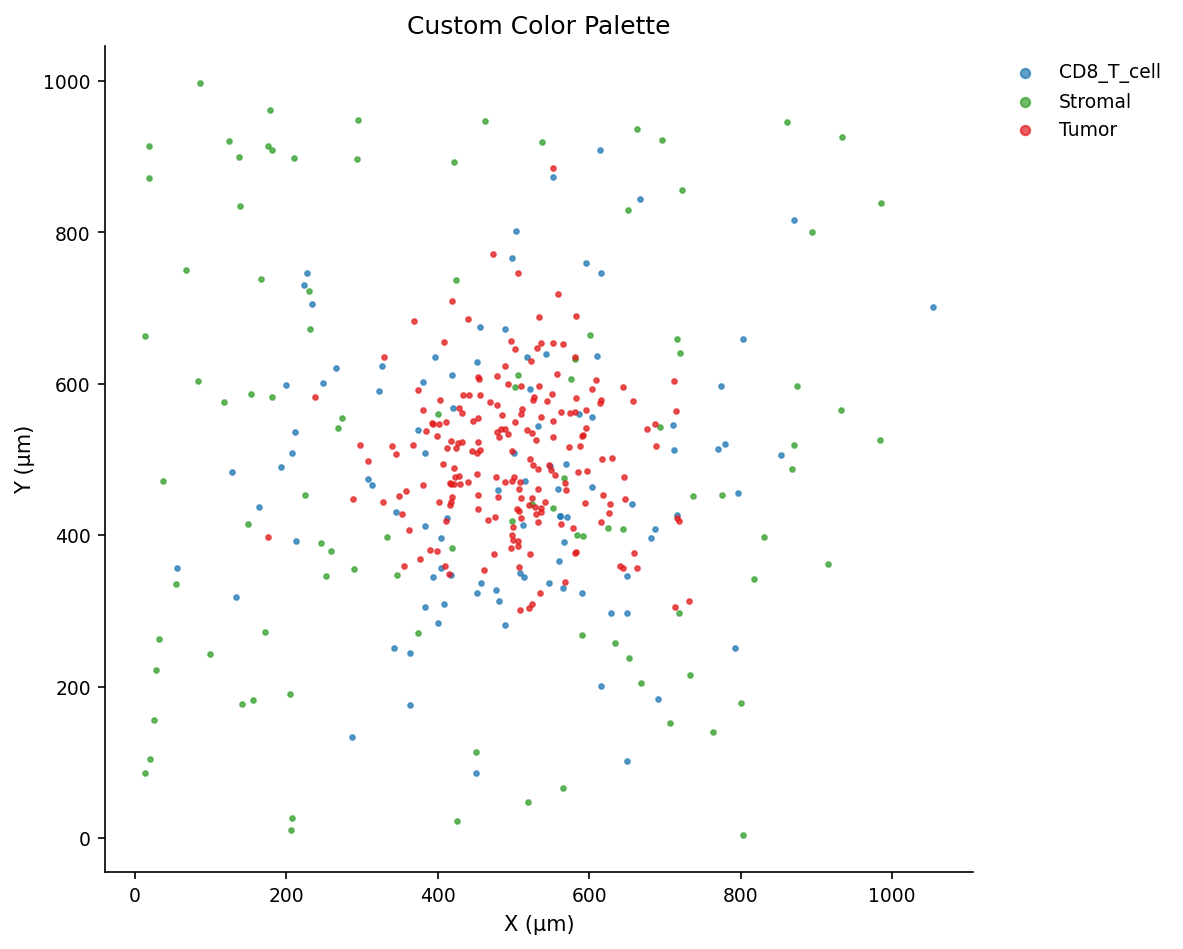

In [5]:
# Use custom colors
custom_colors = {
    'Tumor': '#E31A1C',      # Red
    'CD8_T_cell': '#1F78B4', # Blue
    'Stromal': '#33A02C'     # Green
}

fig, ax = plt.subplots(figsize=(8, 8))
plot_spatial_scatter(tissue, ax=ax, colors=custom_colors)
ax.set_title('Custom Color Palette')
plt.tight_layout()
plt.show()

## Section 2: Spatial Plots

### 2.1 Basic Scatter Plot

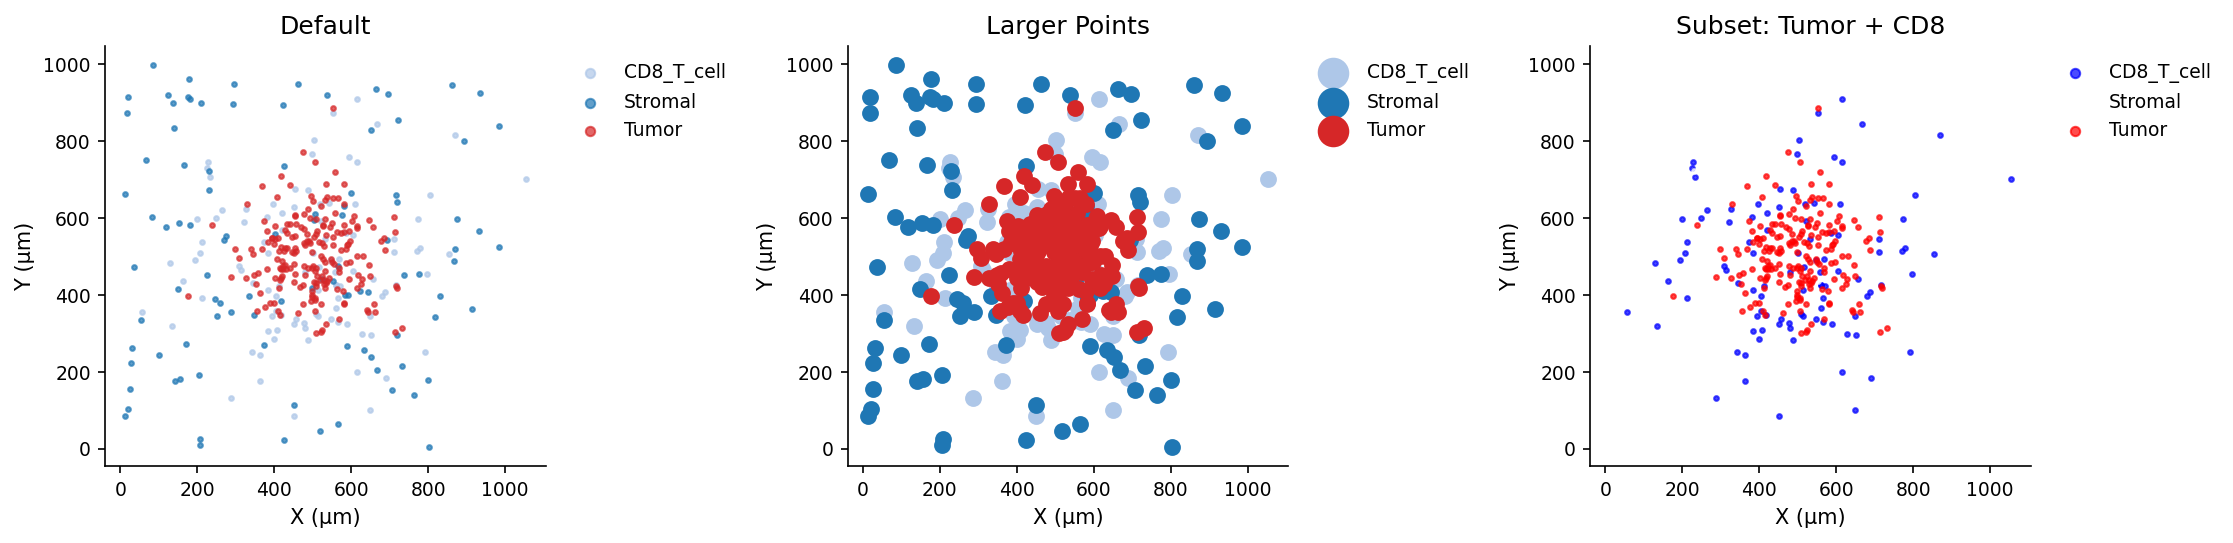

In [6]:
# Basic scatter with options
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Default
plot_spatial_scatter(tissue, ax=axes[0])
axes[0].set_title('Default')

# Larger points, no alpha
plot_spatial_scatter(tissue, ax=axes[1], size=50, alpha=1.0)
axes[1].set_title('Larger Points')

# Highlight certain cell types
colors = {'Tumor': 'red', 'CD8_T_cell': 'blue', 'Stromal':'white'}
plot_spatial_scatter(tissue, ax=axes[2], colors=colors)
axes[2].set_title('Subset: Tumor + CD8')

plt.tight_layout()
plt.show()

### 2.2 Marker Expression

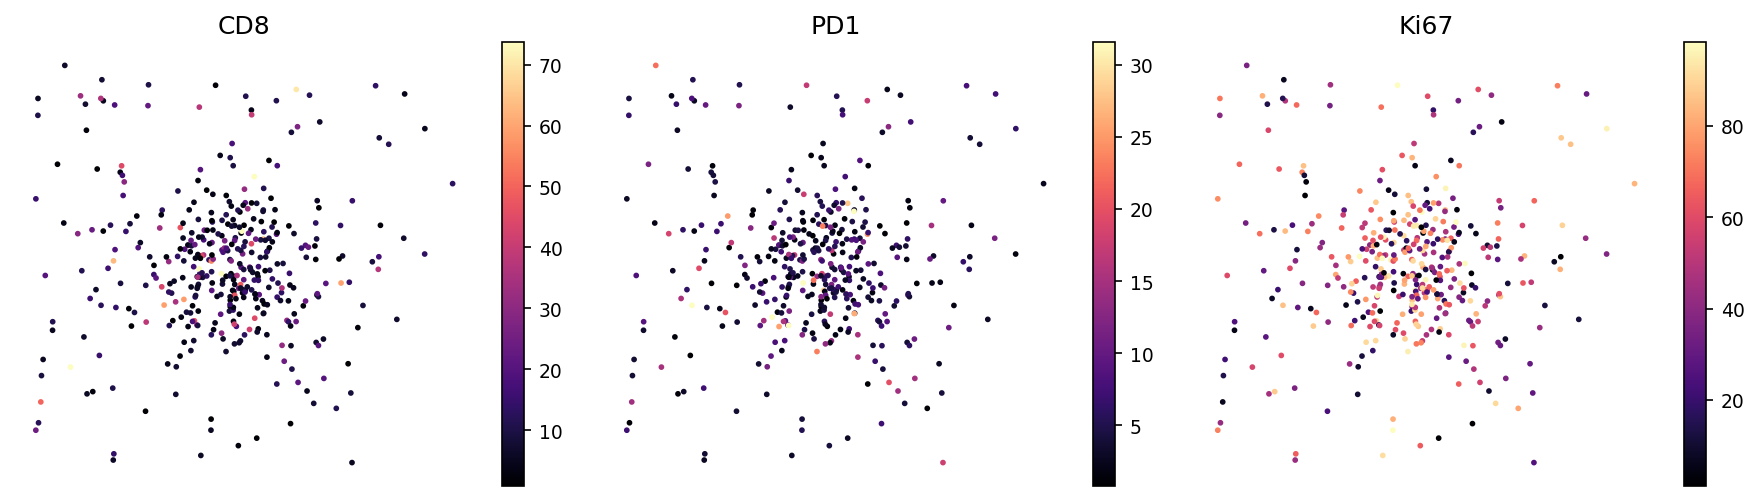

In [23]:
# Plot marker expression
fig = plot_marker_expression(tissue, markers=['CD8', 'PD1', 'Ki67'])

### 2.3 Density Maps

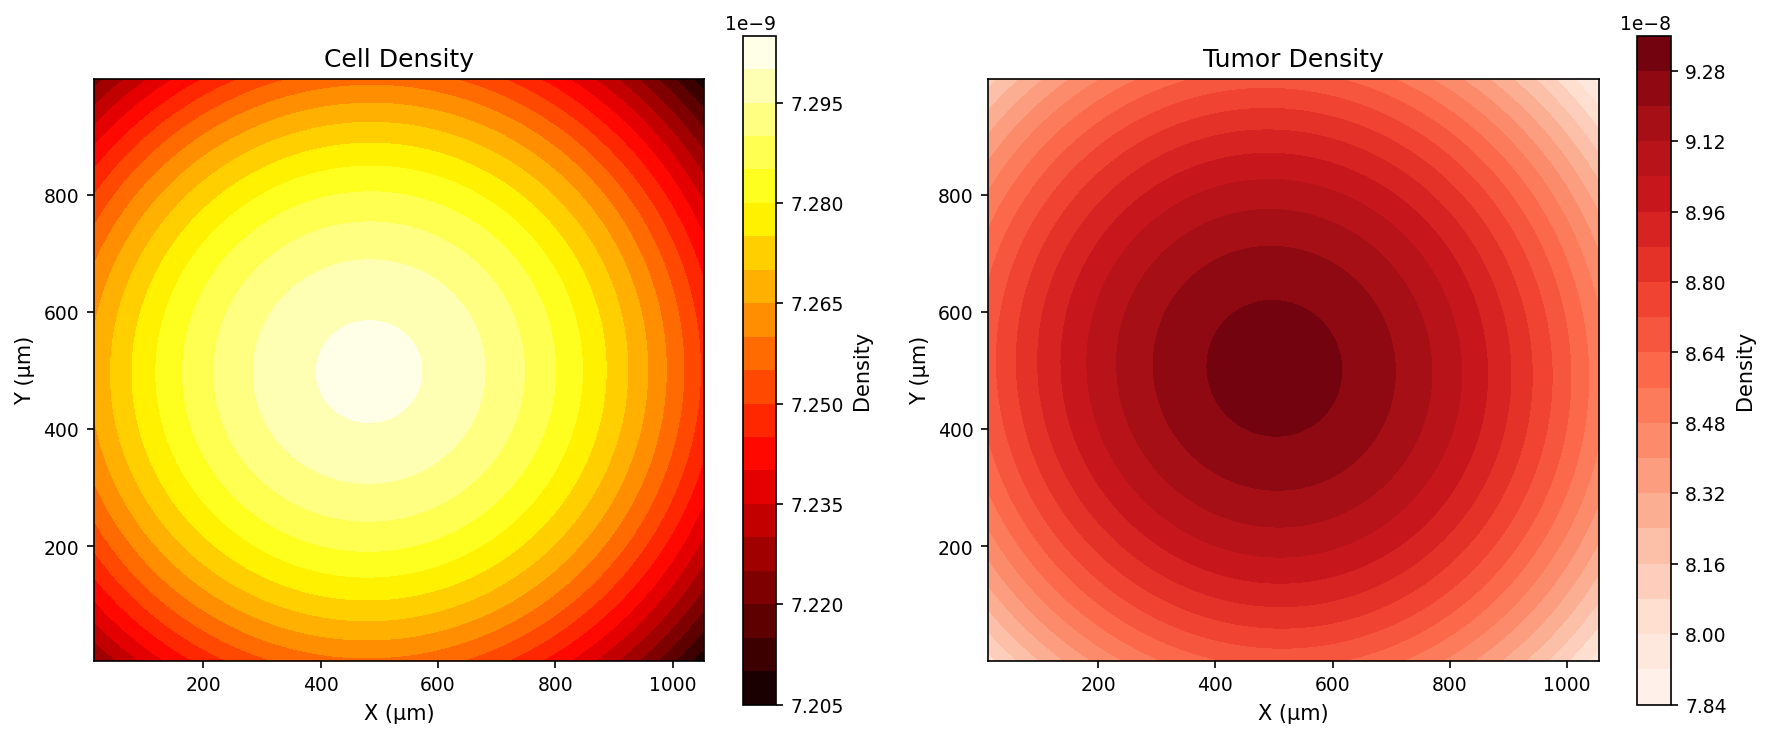

In [10]:
# Density map
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Overall density
plot_density_map(tissue, ax=axes[0], cmap='hot')
axes[0].set_title('Cell Density')

# Density of specific type
plot_density_map(tissue, ax=axes[1], cell_type='Tumor', cmap='Reds')
axes[1].set_title('Tumor Density')

plt.tight_layout()
plt.show()

## Section 3: Statistics Visualization

### 3.1 Ripley's Functions

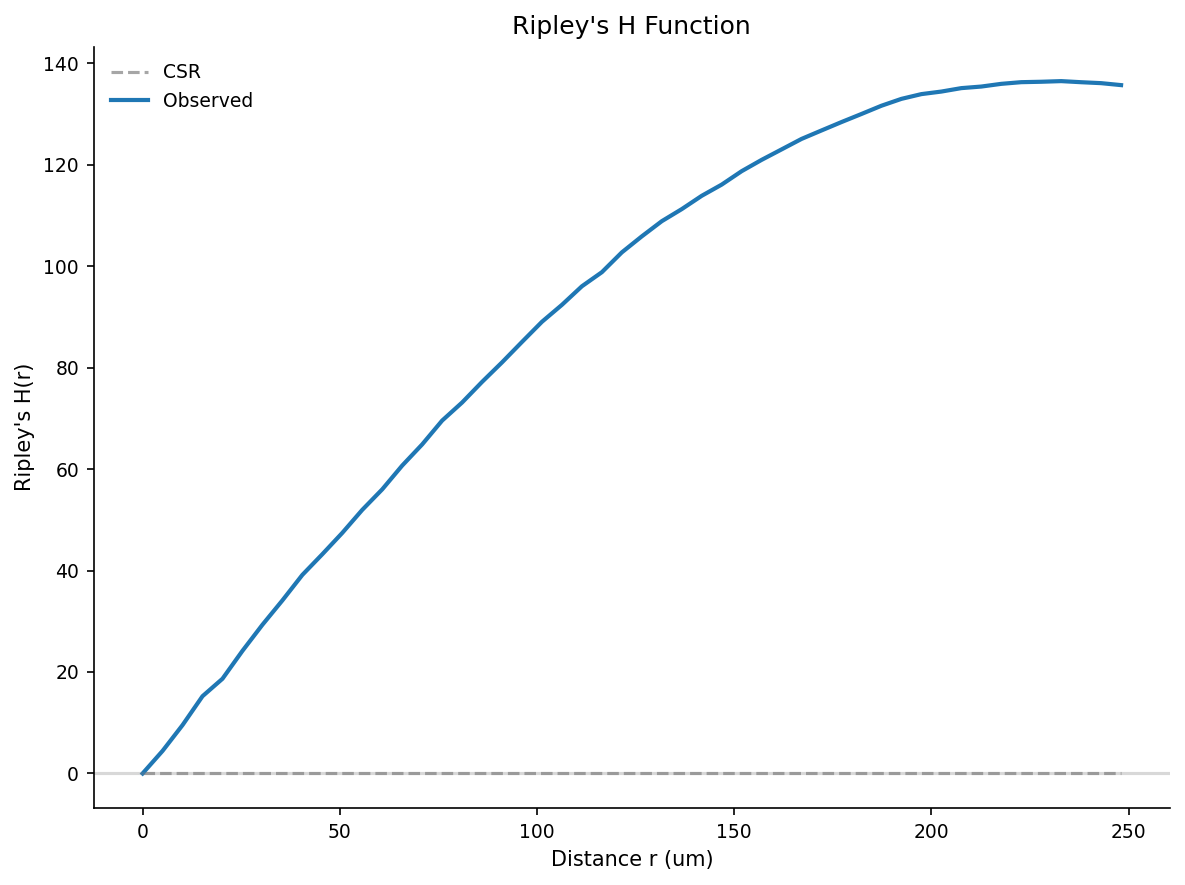

In [13]:
# Ripley's curves
fig, ax = plt.subplots(figsize=(8, 6))
plot_ripleys_curve(tissue, ax=ax)
ax.set_title("Ripley's H Function")
plt.tight_layout()
plt.show()

### 3.2 Colocalization Heatmap

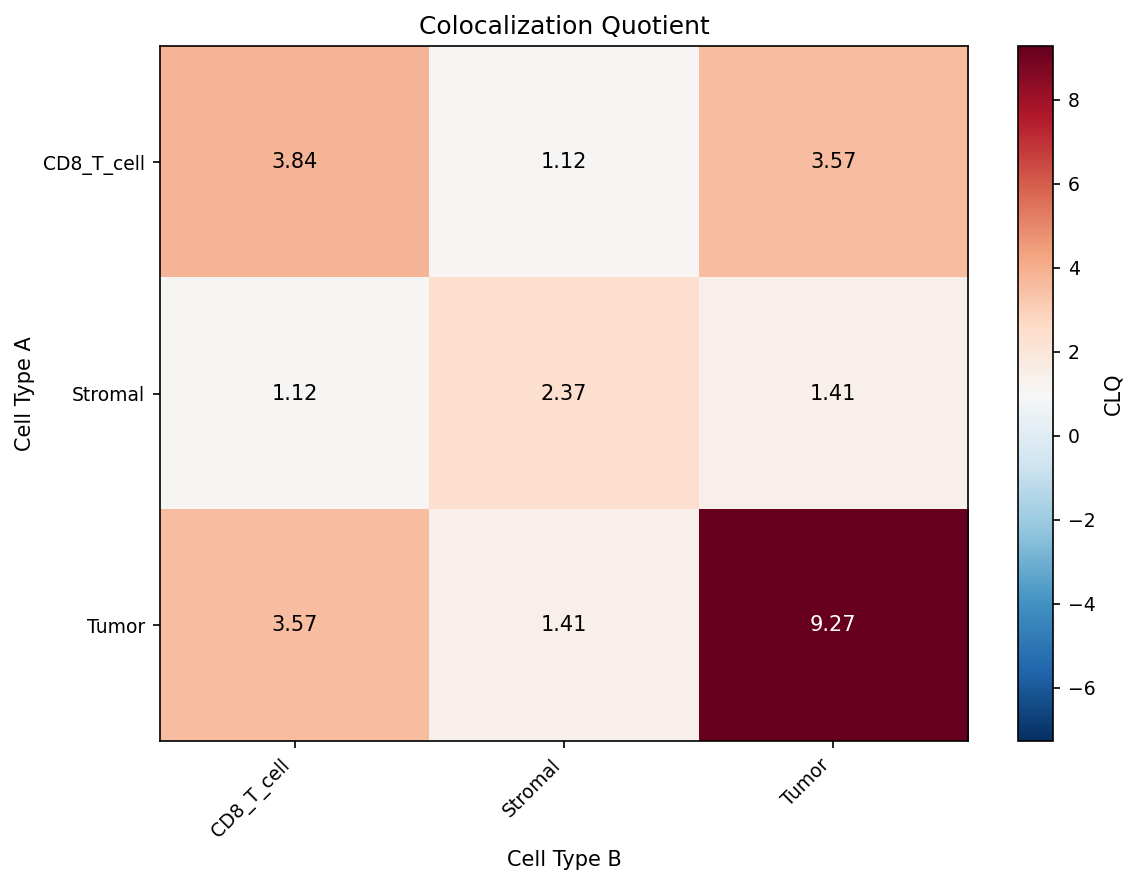

In [15]:
# Compute colocalization
clq = colocalization_matrix(tissue, radius=50.0)

fig, ax = plt.subplots(figsize=(8, 6))
plot_colocalization_heatmap(tissue, ax=ax, annot=True)
ax.set_title('Colocalization Quotient')
plt.tight_layout()
plt.show()

## Section 4: Network Visualization

In [24]:
plot_cell_graph?

Signature:
plot_cell_graph(
    graph: "'CellGraph'",
    layout: 'str' = 'spatial',
    node_color: 'str' = 'cell_type',
    node_size: 'float' = 20,
    edge_alpha: 'float' = 0.3,
    edge_width: 'float' = 0.5,
    colors: 'Optional[Dict[str, str]]' = None,
    show_legend: 'bool' = True,
    ax: "Optional['plt.Axes']" = None,
    **kwargs,
) -> "'plt.Axes'"
Docstring:
Plot cell graph with various layout options.

Parameters
----------
graph : CellGraph
    Cell graph to visualize.
layout : str, default 'spatial'
    Layout algorithm: 'spatial', 'spring', 'kamada_kawai', 'circular'.
node_color : str, default 'cell_type'
    Node coloring: 'cell_type', 'degree', 'component', or a centrality metric.
node_size : float, default 20
    Base node size.
edge_alpha : float, default 0.3
    Edge transparency.
edge_width : float, default 0.5
    Edge line width.
colors : dict, optional
    Custom color mapping for cell types.
show_legend : bool, default True
    Show legend for categorical col

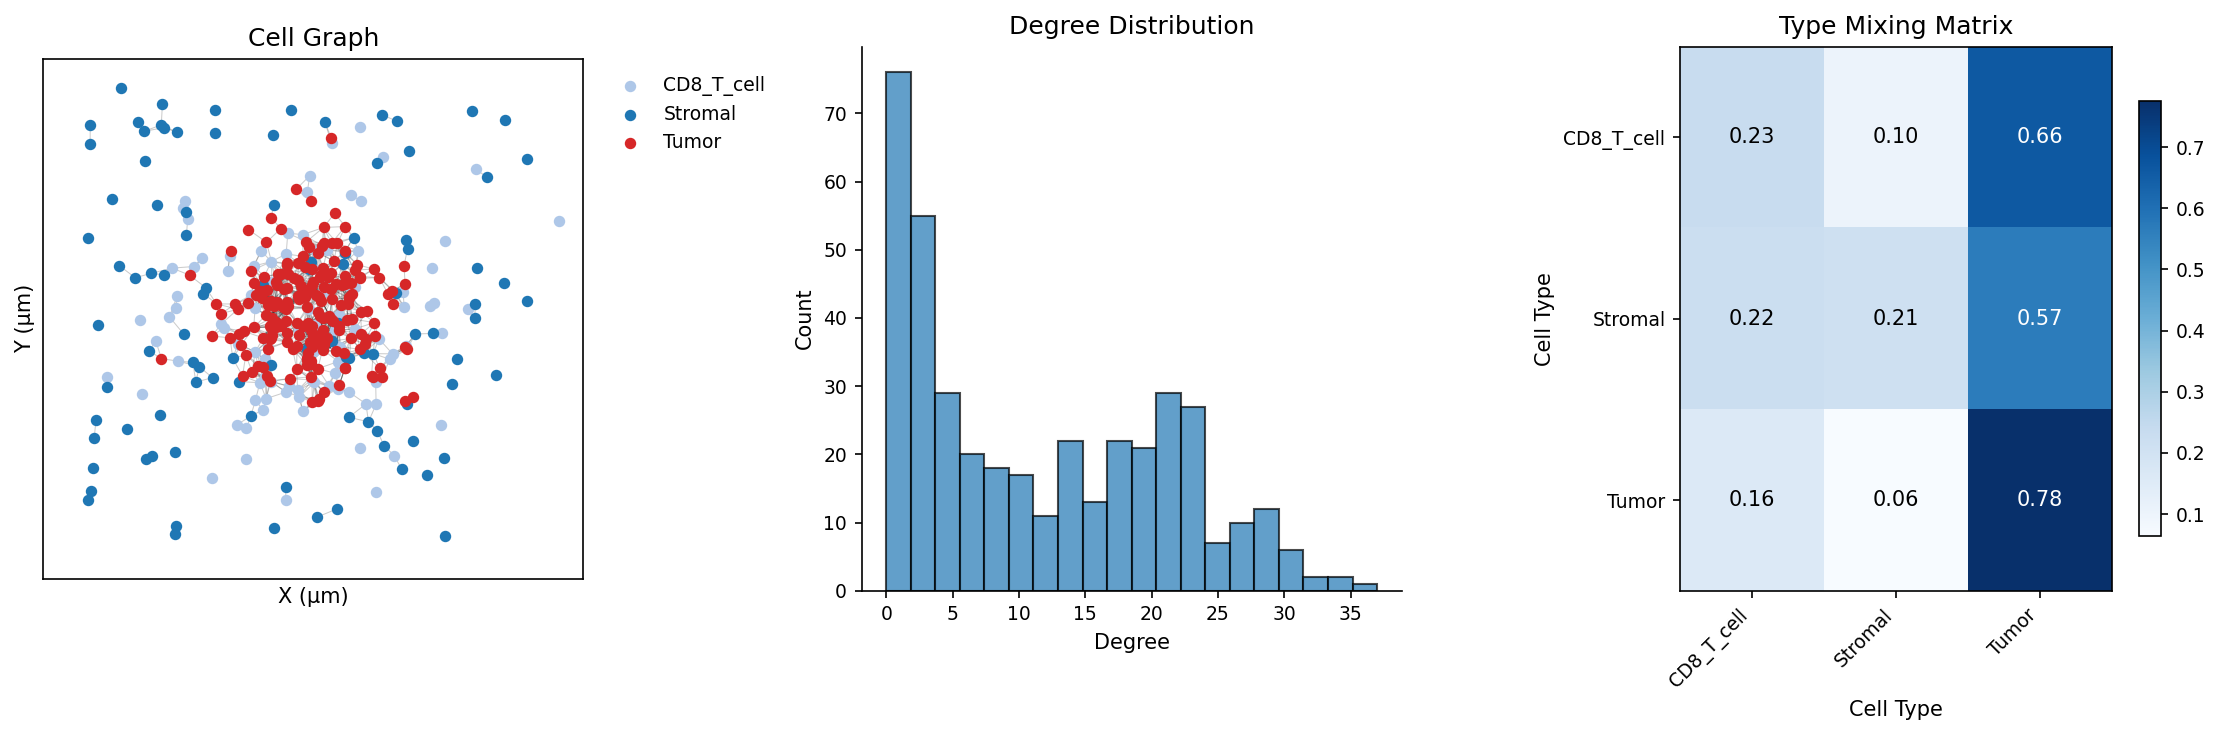

In [25]:
# Build network
graph = CellGraph.from_spatial_data(tissue, method='proximity', radius=50.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Graph on tissue
plot_cell_graph(graph, ax=axes[0], edge_alpha=0.2)
axes[0].set_title('Cell Graph')

# Degree distribution
plot_degree_distribution(graph, ax=axes[1])
axes[1].set_title('Degree Distribution')

# Mixing matrix
plot_type_mixing_matrix(graph, ax=axes[2])
axes[2].set_title('Type Mixing Matrix')

plt.tight_layout()
plt.show()

## Section 5: Multi-Panel Figures

### 5.1 Creating Publication Figures

/var/folders/99/8rc4_4_n7233rmjmy44dmfbs5531hj/T/ipykernel_4668/2093743032.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


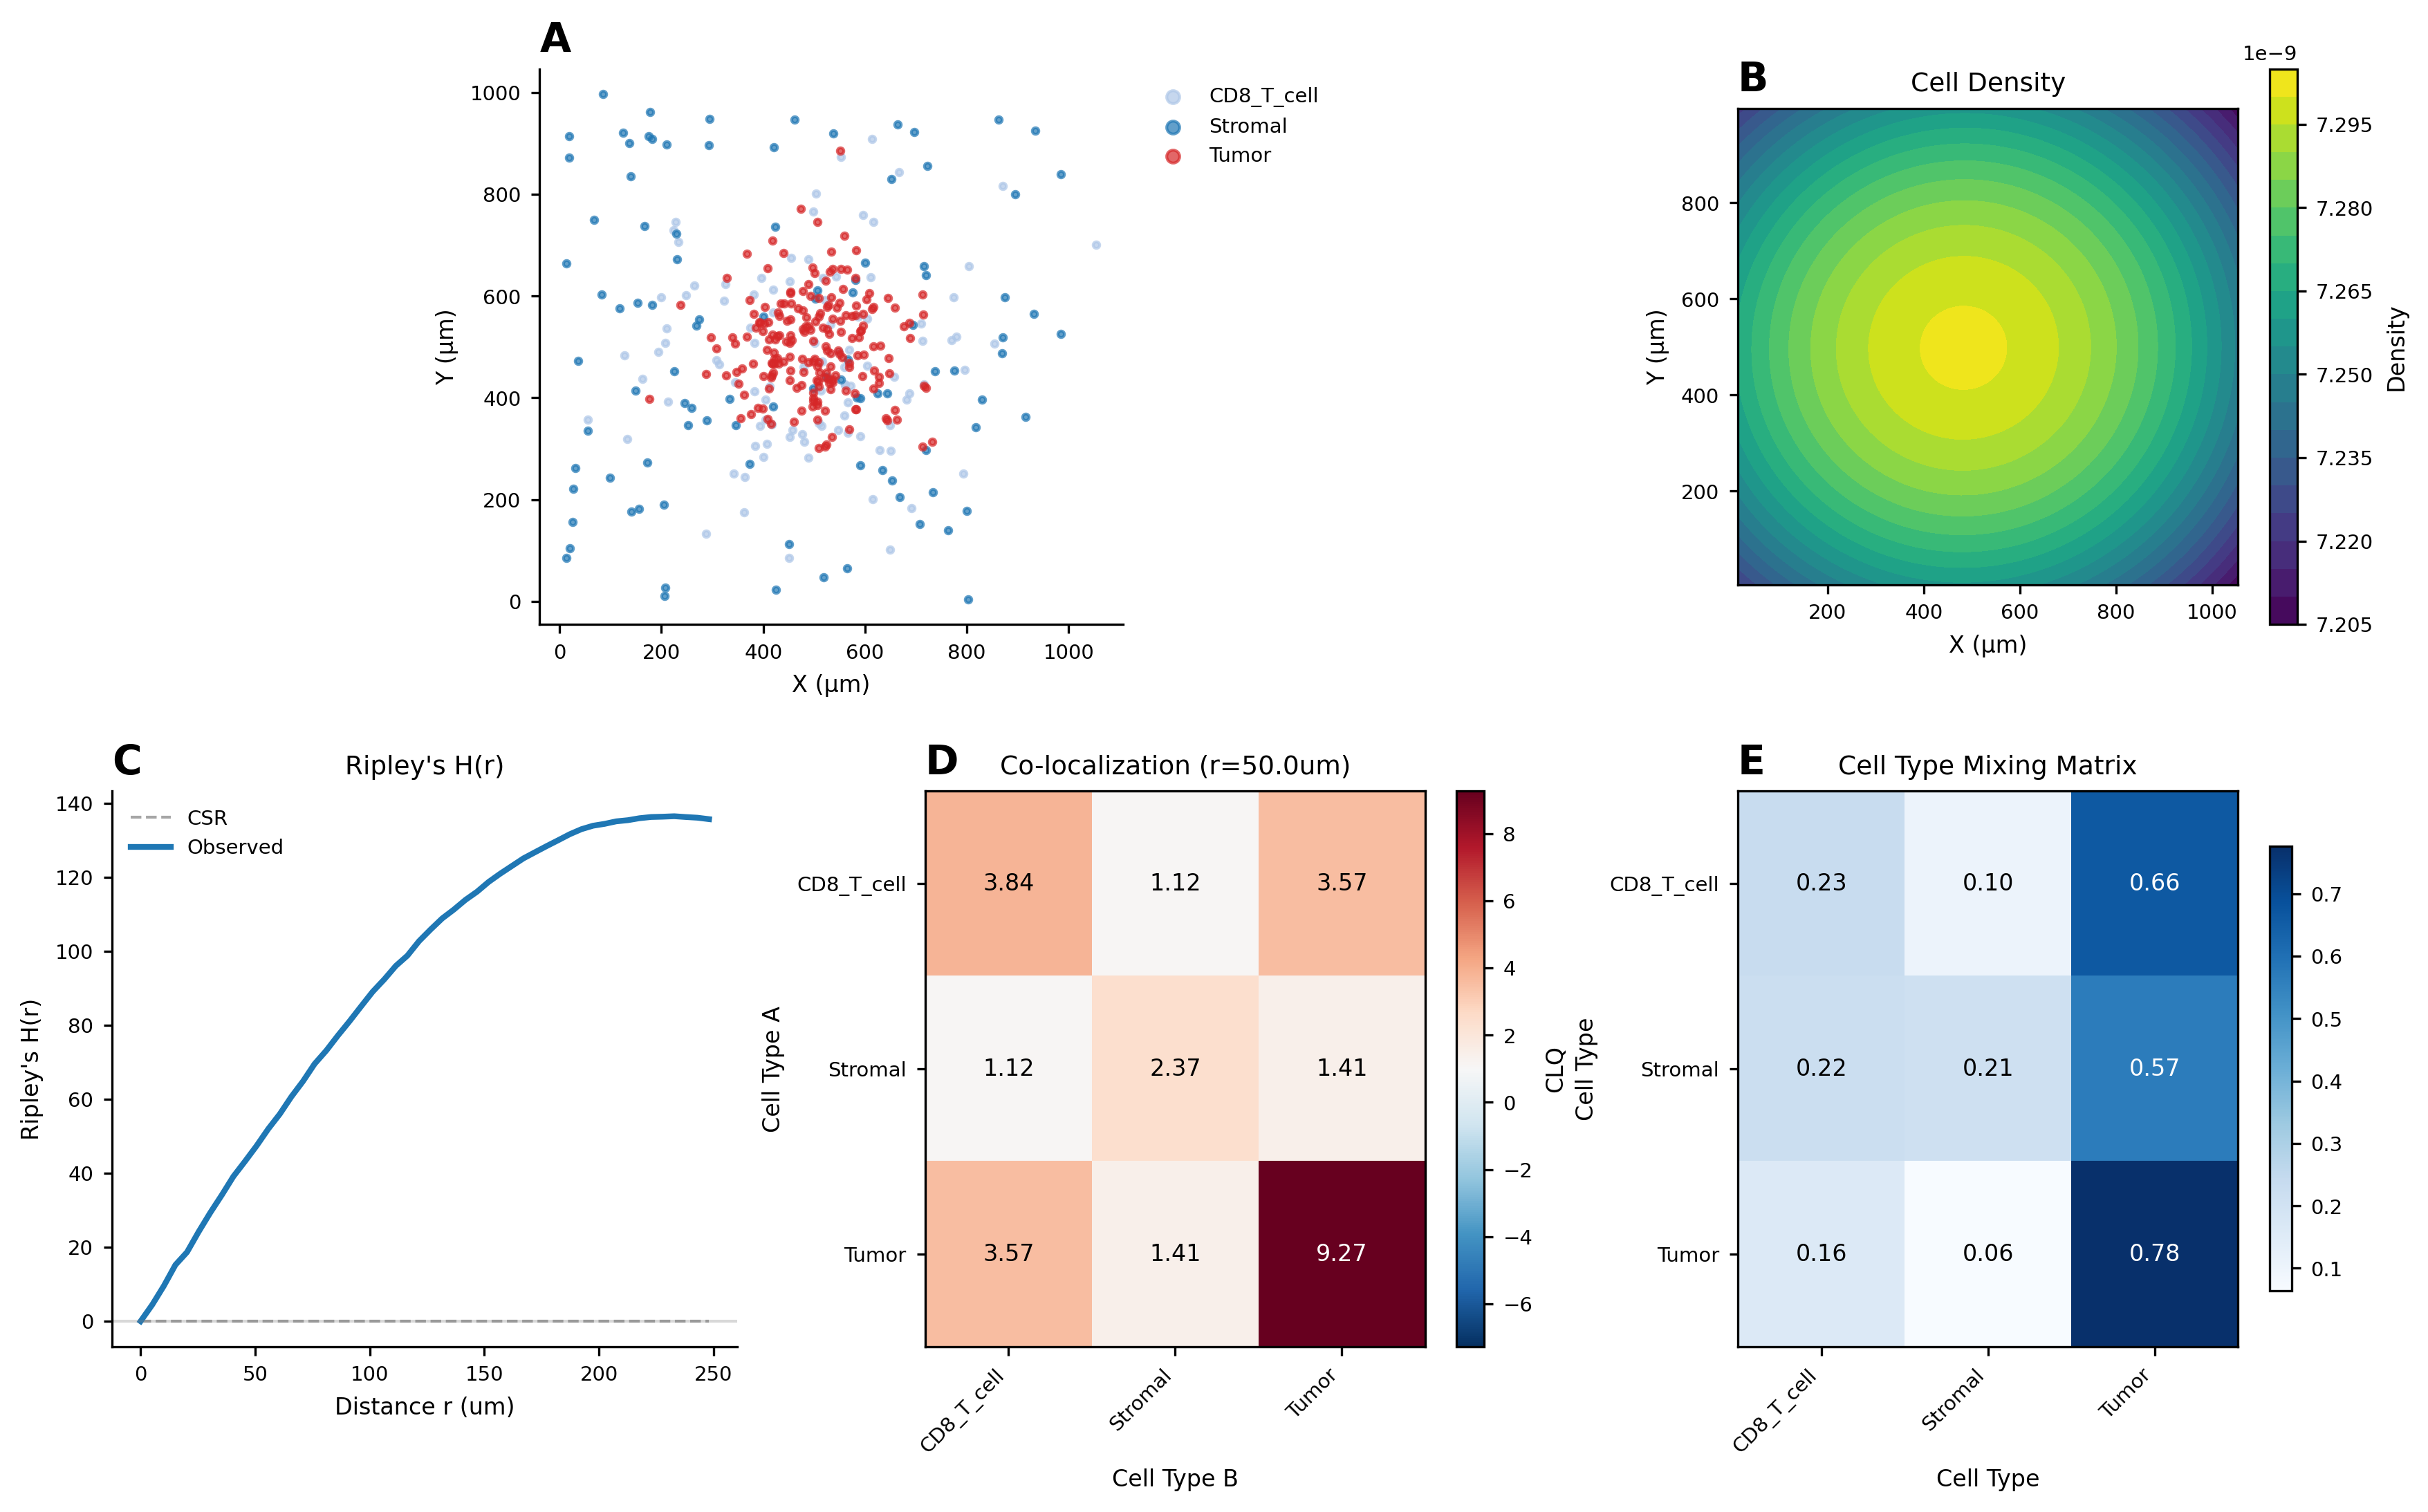

PlotConfig(figsize=(8, 6), dpi=150, font_family='sans-serif', font_size=10, title_size=12, label_size=10, tick_size=9, legend_size=9, line_width=1.5, marker_size=20, alpha=0.7, cell_type_colors={'T_cell': '#1f77b4', 'CD4_T_cell': '#1f77b4', 'CD8_T_cell': '#aec7e8', 'Treg': '#17becf', 'B_cell': '#2ca02c', 'Macrophage': '#ff7f0e', 'M1_Macrophage': '#ff7f0e', 'M2_Macrophage': '#ffbb78', 'Dendritic': '#9467bd', 'NK_cell': '#8c564b', 'Neutrophil': '#e377c2', 'Monocyte': '#7f7f7f', 'Tumor': '#d62728', 'Cancer': '#d62728', 'Tumor_proliferating': '#ff9896', 'Tumor_hypoxic': '#8b0000', 'Fibroblast': '#bcbd22', 'CAF': '#bcbd22', 'Endothelial': '#17becf', 'Epithelial': '#98df8a', 'Unknown': '#c7c7c7', 'Other': '#c7c7c7'}, categorical_palette='default', sequential_cmap='viridis', diverging_cmap='RdBu_r', show_grid=False, grid_alpha=0.3, despine=True)

In [31]:
# Create a publication-quality multi-panel figure
set_publication_style(journal='nature')

fig = plt.figure(figsize=(14, 8))

# Create grid
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Panel A: Spatial scatter (large)
ax_a = fig.add_subplot(gs[0, :2])
plot_spatial_scatter(tissue, ax=ax_a)
ax_a.set_title('A', loc='left', fontweight='bold', fontsize=14)

# Panel B: Density
ax_b = fig.add_subplot(gs[0, 2])
plot_density_map(tissue, ax=ax_b)
ax_b.set_title('B', loc='left', fontweight='bold', fontsize=14)

# Panel C: Ripley's curve
ax_c = fig.add_subplot(gs[1, 0])
plot_ripleys_curve(tissue, ax=ax_c)
ax_c.set_title('C', loc='left', fontweight='bold', fontsize=14)

# Panel D: Colocalization
ax_d = fig.add_subplot(gs[1, 1])
plot_colocalization_heatmap(tissue, ax=ax_d, annot=True)
ax_d.set_title('D', loc='left', fontweight='bold', fontsize=14)

# Panel E: Mixing matrix
ax_e = fig.add_subplot(gs[1, 2])
plot_type_mixing_matrix(graph, ax=ax_e)
ax_e.set_title('E', loc='left', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

set_default_style()

## Section 6: Exporting Figures

### 6.1 Multiple Formats

In [32]:
# Create figure
fig, ax = plt.subplots(figsize=(8, 8))
plot_spatial_scatter(tissue, ax=ax)
ax.set_title('Tissue Sample')

# Save in multiple formats
import tempfile
import os

temp_dir = tempfile.mkdtemp()
base_path = os.path.join(temp_dir, 'figure1')

save_figure(fig, base_path, formats=['png', 'pdf', 'svg'], dpi=300)

print("Saved figures:")
for fmt in ['png', 'pdf', 'svg']:
    path = f"{base_path}.{fmt}"
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f"  {path}: {size:.1f} KB")

plt.close(fig)

Saved figures:
  /var/folders/99/8rc4_4_n7233rmjmy44dmfbs5531hj/T/tmp99vo59xv/figure1.png: 202.4 KB
  /var/folders/99/8rc4_4_n7233rmjmy44dmfbs5531hj/T/tmp99vo59xv/figure1.pdf: 20.3 KB
  /var/folders/99/8rc4_4_n7233rmjmy44dmfbs5531hj/T/tmp99vo59xv/figure1.svg: 85.1 KB


## Exercise: Create a Figure

Create a 2x2 publication figure showing:
1. Spatial distribution colored by cell type
2. CD8 marker expression
3. Cell network
4. Topic distribution (fit a quick LDA model)

Use Nature style and add panel labels (A, B, C, D).

In [ ]:
# Your code here


## Summary

In this tutorial, you learned:

- **Publication styles:** Configuring plots for different journals
- **Spatial plots:** Scatter, density, and marker expression
- **Statistics visualization:** Ripley's curves, colocalization heatmaps
- **Network visualization:** Graphs, degree distributions, mixing matrices
- **Multi-panel figures:** Creating complex layouts with gridspec
- **Export:** Saving figures in multiple formats

**Tips:**
- Always use `ax` parameter for embedding plots in multi-panel figures
- All plot functions return the axes for further customization
- Use `set_publication_style()` early in your notebook
- Export as PDF for vector graphics, PNG for presentations

## Next Steps

- **Tutorial 10: Multi-Sample Analysis** - Comparing cohorts
- **Tutorial 11: PhysiCell Integration** - ABM analysis